<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/mona_kaggle-dktc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd

df_train = pd.read_csv('/content/train (3).csv')
display(df_train.head())

,idx,class,conversation
0,0,협박 대화,지금 너 스스로를 죽여달라고 애원하는 것인가?\n 아닙니다. 죄송합니다.\n 죽을 ...
1,1,협박 대화,길동경찰서입니다.\n9시 40분 마트에 폭발물을 설치할거다.\n네?\n똑바로 들어 ...
2,2,기타 괴롭힘 대화,너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어.\n그만해. 니들 놀리는거 재미...
3,3,갈취 대화,어이 거기\n예??\n너 말이야 너. 이리 오라고\n무슨 일.\n너 옷 좋아보인다?...
4,4,갈취 대화,저기요 혹시 날이 너무 뜨겁잖아요? 저희 회사에서 이 선크림 파는데 한 번 손등에 ...


## 1. 데이터 기본 정보 확인 (Data Info)

In [25]:
# DataFrame의 기본 정보 (데이터 타입, 결측치 등) 확인
display(df_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3950 entries, 0 to 3949
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   idx           3950 non-null   int64 
 1   class         3950 non-null   object
 2   conversation  3950 non-null   object
dtypes: int64(1), object(2)
memory usage: 92.7+ KB


None

## 2. 'class' 컬럼 분포 확인 (Class Distribution)

,count
class,
기타 괴롭힘 대화,1094
갈취 대화,981
직장 내 괴롭힘 대화,979
협박 대화,896


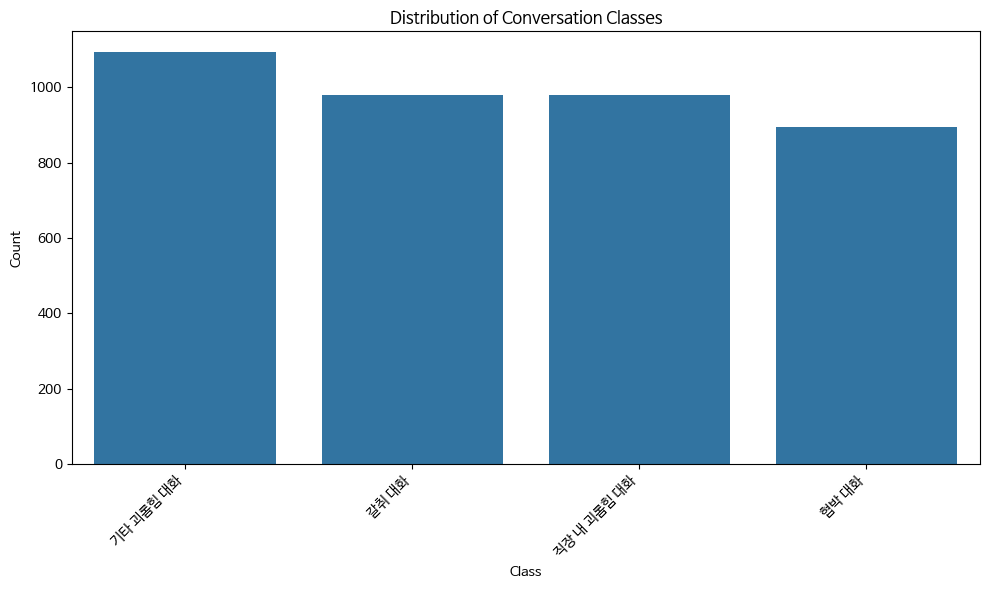

In [26]:
# 'class' 컬럼의 고유 값과 그 분포 확인
class_counts = df_train['class'].value_counts()
display(class_counts)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Distribution of Conversation Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. 'conversation' 컬럼 길이 분석 (Conversation Length Analysis)

,conversation_length
count,3950.000000
mean,226.570886
std,104.560310
min,41.000000
25%,156.000000
50%,203.000000
75%,270.000000
max,874.000000


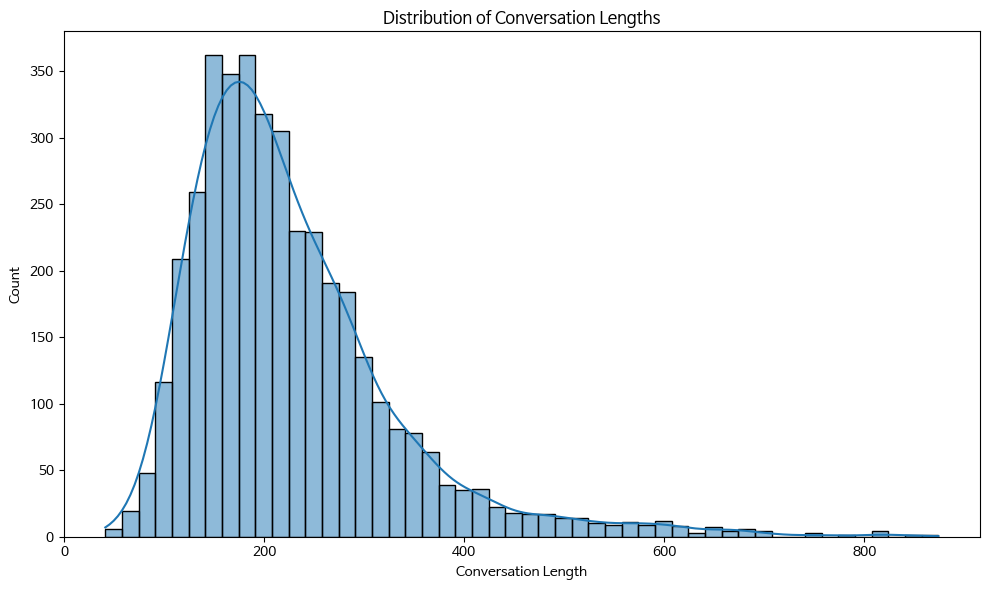

In [27]:
# 'conversation' 컬럼의 텍스트 길이 계산
df_train['conversation_length'] = df_train['conversation'].apply(len)

# 길이 통계량 확인
display(df_train['conversation_length'].describe())

# 길이 분포 시각화
plt.figure(figsize=(10, 6))
sns.histplot(df_train['conversation_length'], bins=50, kde=True)
plt.title('Distribution of Conversation Lengths')
plt.xlabel('Conversation Length')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4. 데이터 전처리 (Data Preprocessing)

딥러닝 모델 학습을 위해 텍스트 데이터를 전처리하고, 'class' 레이블을 수치형으로 변환합니다. 먼저, 한글 폰트 설정을 하여 시각화 시 깨짐 현상을 방지합니다.

In [28]:
# 한글 폰트 설정 (Mac, Linux, Colab 환경에 따라 다르게 설정)
import matplotlib.font_manager as fm

# Colab 환경 체크 및 폰트 설치
!apt-get update -qq
!apt-get install fonts-nanum* -qq

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


### 4.1. 클래스 레이블 수치화 (Label Encoding)

In [29]:
from sklearn.preprocessing import LabelEncoder

# 'class' 컬럼의 고유 값 확인
print("Original classes:", df_train['class'].unique())

# LabelEncoder 초기화 및 학습
label_encoder = LabelEncoder()
df_train['class_encoded'] = label_encoder.fit_transform(df_train['class'])

# 인코딩된 클래스와 원래 클래스 매핑 확인
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Class to ID mapping:", class_mapping)

# 인코딩된 데이터의 분포 확인
display(df_train[['class', 'class_encoded']].head())

Original classes: ['협박 대화' '기타 괴롭힘 대화' '갈취 대화' '직장 내 괴롭힘 대화']
Class to ID mapping: {'갈취 대화': np.int64(0), '기타 괴롭힘 대화': np.int64(1), '직장 내 괴롭힘 대화': np.int64(2), '협박 대화': np.int64(3)}


,class,class_encoded
0,협박 대화,3
1,협박 대화,3
2,기타 괴롭힘 대화,1
3,갈취 대화,0
4,갈취 대화,0


### 4.2. 텍스트 데이터 전처리 및 토큰화

In [30]:
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 텍스트 정제 함수
def clean_text(text):
    text = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣ\s]', '', text) # 한글, 공백만 남기고 제거
    return text

df_train['cleaned_conversation'] = df_train['conversation'].apply(clean_text)

# 테스트 데이터 로드 및 전처리
df_test = pd.read_csv('/content/test (3).csv')
df_test['cleaned_conversation'] = df_test['text'].apply(clean_text) # 이 줄을 수정했습니다.

# Tokenizer 생성 및 훈련 데이터에 학습
# OOV(Out-Of-Vocabulary) 토큰을 위해 num_words보다 vocab_size를 크게 설정할 수 있음
tokenizer = Tokenizer(num_words=None, oov_token='<unk>') # 모든 단어를 사용하도록 num_words=None 설정
tokenizer.fit_on_texts(df_train['cleaned_conversation'])

# 텍스트를 시퀀스로 변환
X_train_seq = tokenizer.texts_to_sequences(df_train['cleaned_conversation'])
X_test_seq = tokenizer.texts_to_sequences(df_test['cleaned_conversation'])

# 시퀀스 길이 분포 확인 (패딩 길이를 결정하기 위함)
train_lengths = [len(s) for s in X_train_seq]
print("Train sequence length stats:", pd.Series(train_lengths).describe())

# 최대 시퀀스 길이 설정 (예: 99.9%에 해당하는 길이 사용)
MAX_SEQUENCE_LENGTH = int(pd.Series(train_lengths).quantile(0.99))
print(f"Max sequence length for padding: {MAX_SEQUENCE_LENGTH}")

# 시퀀스 패딩
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

# 결과 확인
print("Shape of X_train_padded:", X_train_padded.shape)
print("Shape of X_test_padded:", X_test_padded.shape)
print("Example of padded sequence:", X_train_padded[0])

Train sequence length stats: count    3950.000000
mean       56.800759
std        26.950083
min        10.000000
25%        39.000000
50%        51.000000
75%        67.000000
max       223.000000
dtype: float64
Max sequence length for padding: 160
Shape of X_train_padded: (3950, 160)
Shape of X_test_padded: (500, 160)
Example of padded sequence: [   14     2 16188  9371 16189 16190    78    11   604  3733   263  3275
  9372  4371 16191    49    12  1515 16192    42   972    50  3734    50
  1217     4  2183  3276    11    42   972 16193  6706    41  6707  9373
  2903     4  3277  6708   363  6707  6709   147  1068    18    10 16194
  9374   315    26  1068     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0 

### 4.3. 훈련 및 검증 세트 분리

In [31]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# 레이블 인코딩된 'class_encoded'를 One-hot Encoding
y_train = to_categorical(df_train['class_encoded'])

# 훈련 세트와 검증 세트 분리
X_train, X_val, y_train, y_val = train_test_split(
    X_train_padded, y_train, test_size=0.2, random_state=42, stratify=df_train['class_encoded']
)

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)

Shape of X_train: (3160, 160)
Shape of y_train: (3160, 4)
Shape of X_val: (790, 160)
Shape of y_val: (790, 4)


## 5. 딥러닝 모델 구축 및 학습 (Deep Learning Model Construction and Training)

### 5.1. 모델 정의 (Model Definition)

텍스트 분류를 위한 Bidirectional LSTM 모델을 정의합니다. 임베딩 레이어를 통해 단어를 벡터 공간에 매핑하고, LSTM 레이어로 시퀀스 데이터를 처리합니다.

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

VOCAB_SIZE = len(tokenizer.word_index) + 1 # 토크나이저의 단어 인덱스 + OOV 토큰
EMBEDDING_DIM = 100 # 임베딩 벡터의 차원
NUM_CLASSES = len(label_encoder.classes_) # 분류할 클래스 수

model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 5.2. 모델 컴파일 (Model Compilation)

모델 학습을 위한 옵티마이저, 손실 함수, 평가 지표를 설정합니다.

In [33]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### 5.3. 모델 학습 (Model Training)

훈련 데이터와 검증 데이터를 사용하여 모델을 학습합니다. 과적합을 방지하기 위해 EarlyStopping 콜백을 사용합니다.

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

history = model.fit(
    X_train, y_train,
    epochs=10, # 적절한 에포크 수 설정
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, model_checkpoint]
)

# 학습 곡선 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.3131 - loss: 1.3217

99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 461ms/step - accuracy: 0.4275 - loss: 1.1887 - val_accuracy: 0.6253 - val_loss: 0.9111
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.7737 - loss: 0.6404

99/99 ━━━━━━━━━━━━━━━━━━━━ 77s 411ms/step - accuracy: 0.7911 - loss: 0.5941 - val_accuracy: 0.7722 - val_loss: 0.6321
Epoch 3/10
85/99 ━━━━━━━━━━━━━━━━━━━━ 5s 394ms/step - accuracy: 0.9527 - loss: 0.2322

In [ ]:
# 최종 검증 정확도 및 손실 출력
final_val_accuracy = history.history['val_accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"최종 검증 정확도 (Final Validation Accuracy): {final_val_accuracy:.4f}")
print(f"최종 검증 손실 (Final Validation Loss): {final_val_loss:.4f}")

### 6.2. 검증 세트에 대한 상세 평가 (Detailed Evaluation on Validation Set)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 모델 평가
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"검증 손실 (Validation Loss): {loss:.4f}")
print(f"검증 정확도 (Validation Accuracy): {accuracy:.4f}")

# 검증 데이터에 대한 예측 수행
y_val_pred_probs = model.predict(X_val)
y_val_pred_classes = np.argmax(y_val_pred_probs, axis=1)
y_val_true_classes = np.argmax(y_val, axis=1)

# 클래스 레이블 (원본 한글 이름)
target_names = label_encoder.classes_

# 분류 리포트 출력
print("\nClassification Report on Validation Set:")
print(classification_report(y_val_true_classes, y_val_pred_classes, target_names=target_names))

# 혼동 행렬 출력
print("\nConfusion Matrix on Validation Set:")
conf_matrix = confusion_matrix(y_val_true_classes, y_val_pred_classes)
display(pd.DataFrame(conf_matrix, index=target_names, columns=target_names))

## 6. 모델 성능 평가 (Model Evaluation)

### 6.1. 테스트 데이터 예측 및 평가

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 테스트 데이터에 대한 예측 수행
predictions = model.predict(X_test_padded)
y_pred_classes = np.argmax(predictions, axis=1)

# Submission 파일 생성을 위한 원래 클래스 이름으로 디코딩
y_pred_labels = label_encoder.inverse_transform(y_pred_classes)

# 테스트 데이터에는 실제 레이블이 없으므로, 분류 보고서 및 혼동 행렬은 생성하지 않습니다.
# 대신 예측 결과를 submission 파일로 저장합니다.

print("Predicted classes for test data (first 5):")
for i in range(5):
    print(f"  - Predicted ID: {y_pred_classes[i]}, Predicted Label: {y_pred_labels[i]}")

## 7. Submission 파일 생성

In [ ]:
# submission (2).csv 파일을 로드합니다.
submission_df = pd.read_csv('/content/submission (2).csv')

# 예측된 레이블을 'class' 컬럼에 할당합니다.
submission_df['class'] = y_pred_labels

# 결과 확인
display(submission_df.head())

# submission.csv 파일로 저장합니다.
submission_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' has been created.")